In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [ ]:
''' 
This notebook performs volatility forecasting using past observations:
    Historical data is split into training (2014-2023) and test (2024) periods
    An N-BEATS neural network is trained
    Model results scored and recored
    Forecast is plotted againts true observations

'''

In [2]:
# load returns.csv
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)
returns.tz_localize('UTC', axis='index')
print(returns.info())
returns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237312,0.158325
2014-01-03,0.231106,-0.727065
2014-01-06,-0.361792,-0.516652
2014-01-07,0.285965,0.264468
2014-01-08,1.051503,-0.114382
...,...,...
2024-06-24,0.121303,-0.174209
2024-06-25,-0.316753,0.420722
2024-06-26,0.023427,-0.215266


In [3]:
# Split data into train, validation, and test sets
train_split = '2022-01-01'
val_split = '2023-01-01' 
train = returns.loc[:train_split]
val = returns.loc[train_split:val_split]
test = returns.loc[val_split:]


# check

print(train.shape, val.shape, test.shape)
print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

print("Train")
print(train)
print("Validation")
print(val)
print("Test")
print(test)


(2084, 2) (260, 2) (390, 2)
2014-01-02 00:00:00 2021-12-31 00:00:00
2022-01-03 00:00:00 2022-12-30 00:00:00
2023-01-02 00:00:00 2024-06-28 00:00:00
Train
            EURUSD=X     CAD=X
Date                          
2014-01-02  0.237312  0.158325
2014-01-03  0.231106 -0.727065
2014-01-06 -0.361792 -0.516652
2014-01-07  0.285965  0.264468
2014-01-08  1.051503 -0.114382
...              ...       ...
2021-12-27 -0.077202 -0.027173
2021-12-28 -0.210705  0.050982
2021-12-29  0.203328 -0.134644
2021-12-30 -0.237256  0.401010
2021-12-31 -0.298839 -0.309174

[2084 rows x 2 columns]
Validation
            EURUSD=X     CAD=X
Date                          
2022-01-03 -0.671672  0.427647
2022-01-04  0.730721 -0.626146
2022-01-05 -0.367810 -0.164740
2022-01-06  0.438435  0.264733
2022-01-07 -0.234325 -0.146863
...              ...       ...
2022-12-26 -0.345386  0.608058
2022-12-27 -0.240626 -0.258560
2022-12-28 -0.236044 -0.028715
2022-12-29  0.550099 -0.074414
2022-12-30 -0.348545  0.296373

[26

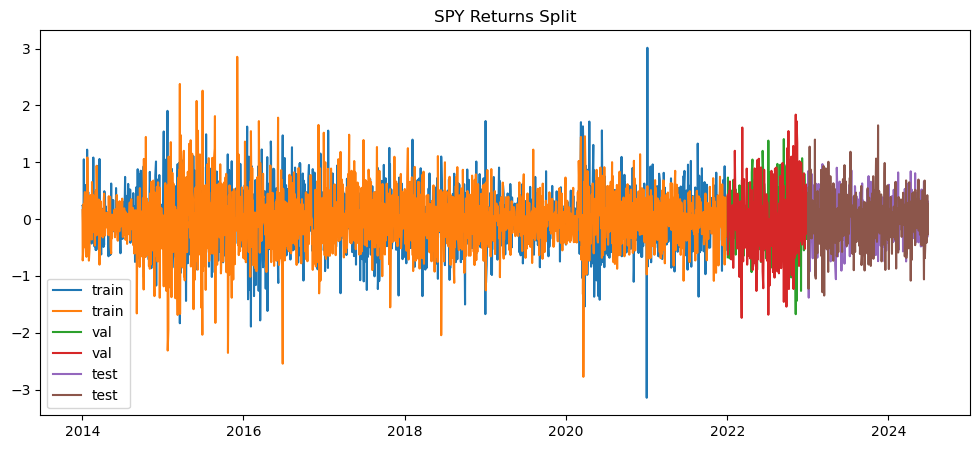

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="train")
plt.plot(val.index, val, label="val")
plt.plot(test.index, test, label="test")
plt.title("SPY Returns Split")
plt.legend()
plt.show()

In [5]:
returns.reset_index(inplace=True)
train.reset_index(inplace=True)
val.reset_index(inplace=True)
test.reset_index(inplace=True)

In [6]:
returns

,Date,EURUSD=X,CAD=X
0,2014-01-02,0.237312,0.158325
1,2014-01-03,0.231106,-0.727065
2,2014-01-06,-0.361792,-0.516652
3,2014-01-07,0.285965,0.264468
4,2014-01-08,1.051503,-0.114382
...,...,...,...
2729,2024-06-24,0.121303,-0.174209
2730,2024-06-25,-0.316753,0.420722
2731,2024-06-26,0.023427,-0.215266
2732,2024-06-27,0.317694,-0.275549


In [11]:
series_ts = TimeSeries.from_dataframe(
    returns,
    time_col='Date',
    value_cols=list(returns.columns)[1:],
    # fill_missing_dates=True,
    fillna_value=0.0,
    freq='B'
).astype(np.float32)

train_ts = TimeSeries.from_dataframe(
    train, 
    time_col='Date', 
    value_cols=list(returns.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

val_ts = TimeSeries.from_dataframe(
    val, 
    time_col='Date', 
    value_cols=list(returns.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )
    
test_ts = TimeSeries.from_dataframe(
    test, 
    time_col='Date', 
    value_cols=list(returns.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

In [ ]:
train_ts

,SPY,AMZN
Date,,
2014-01-03,-0.384451,-0.016418
2014-01-06,-0.708814,-0.289787
2014-01-07,1.117807,0.614204
2014-01-08,0.977313,0.021748
2014-01-09,-0.226412,0.065415
...,...,...
2021-12-27,-0.817802,1.415238
2021-12-28,0.584372,-0.081734
2021-12-29,-0.855492,0.127921


In [16]:
print(type(series_ts))

<class 'darts.timeseries.TimeSeries'>


In [ ]:
# check null values
null_count_df = series_ts.to_dataframe()
print(null_count_df)
print(null_count_df.isna().sum())

# print where it is null if any
null_count_df[null_count_df.isna().any(axis=1)] 

            EURUSD=X     CAD=X
Date                          
2014-01-02  0.237312  0.158325
2014-01-03  0.231106 -0.727065
2014-01-06 -0.361792 -0.516652
2014-01-07  0.285965  0.264468
2014-01-08  1.051503 -0.114382
...              ...       ...
2024-06-24  0.121303 -0.174209
2024-06-25 -0.316753  0.420722
2024-06-26  0.023427 -0.215266
2024-06-27  0.317694 -0.275549
2024-06-28 -0.037943  0.265573

[2737 rows x 2 columns]
EURUSD=X    0
CAD=X       0
dtype: int64


,EURUSD=X,CAD=X
Date,,


In [22]:
# Scaler
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled = scaler.fit_transform(train_ts)
val_scaled = scaler.transform(val_ts)
test_scaled = scaler.transform(test_ts)
series_scaled = scaler.transform(series_ts)

In [23]:
# Define nbeats model
seed = 42
nbeats_name = "nbeats"

model_nbeats = NBEATSModel(
    input_chunk_length=20,       # use last 20 observations
    output_chunk_length=1,       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=2,
    num_blocks=2,
    num_layers=2,
    layer_widths=64,
    n_epochs=10, 
    batch_size=32,
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 30.7 K | train
-------------------------------------------------------------
30.2 K    Trainable params
565       Non-trainable params
30.7 K    Total params
0.123     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [24]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

In [25]:
one_pred = model_nbeats.predict(n=1, series=train_scaled)
print(one_pred) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

            EURUSD=X     CAD=X
Date                          
2022-01-03   0.03606 -0.026553

shape: (1, 2, 1), freq: B, size: 16.00 B


In [26]:
print(len(train), len(val), len(test))

2084 260 390


In [27]:
print(series_scaled.start_time(), series_scaled.end_time())
print(test['Date'].iloc[0])

2014-01-02 00:00:00 2024-06-28 00:00:00
2023-01-02 00:00:00


In [28]:
# historical_forecasts rolls forward through the test period
pred_scaled = model_nbeats.historical_forecasts(
    series=series_scaled,
    start=test['Date'].iloc[0],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [29]:
pred_ts = scaler.inverse_transform(pred_scaled) 
print(type(pred_scaled))
print(type(pred_ts))
print(type(test_ts))

print(pred_scaled)
print(pred_ts)
print(test_ts)

<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
            EURUSD=X     CAD=X
Date                          
2023-01-02  0.026869  0.000236
2023-01-03  0.005727 -0.012663
2023-01-04  0.021148 -0.017947
2023-01-05  0.052572 -0.038693
2023-01-06  0.039414 -0.014438
...              ...       ...
2024-06-24  0.051221 -0.022330
2024-06-25  0.048569 -0.017435
2024-06-26  0.011287 -0.000851
2024-06-27  0.024148 -0.023478
2024-06-28  0.060903 -0.044270

shape: (390, 2, 1), freq: B, size: 6.09 KB
            EURUSD=X     CAD=X
Date                          
2023-01-02  0.017937  0.040336
2023-01-03 -0.047150  0.004029
2023-01-04  0.000323 -0.010846
2023-01-05  0.097066 -0.069243
2023-01-06  0.056557 -0.000968
...              ...       ...
2024-06-24  0.092907 -0.023183
2024-06-25  0.084740 -0.009406
2024-06-26 -0.030034  0.037277
2024-06-27  0.009558 -0.026414
2024-06-28  0.122712 -0.084940

shape: (390, 2, 1), freq: B, size: 

In [ ]:
# evaluate model
scores = {}
for col in list(returns.columns)[1:]:   
    rootmeansquarederr = rmse(test_ts, pred_ts)
    sMAPE = smape(test_ts, pred_ts)

    scores[col] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE} 

scores

{'EURUSD=X': {'RMSE': np.float64(0.3959086678949652),
  'sMAPE': np.float64(169.67794087209336)},
 'CAD=X': {'RMSE': np.float64(0.3959086678949652),
  'sMAPE': np.float64(169.67794087209336)}}

In [42]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv('../results/tables/nbeats_scores.csv')
scores_df

,RMSE,sMAPE
EURUSD=X,0.395909,169.677941
CAD=X,0.395909,169.677941


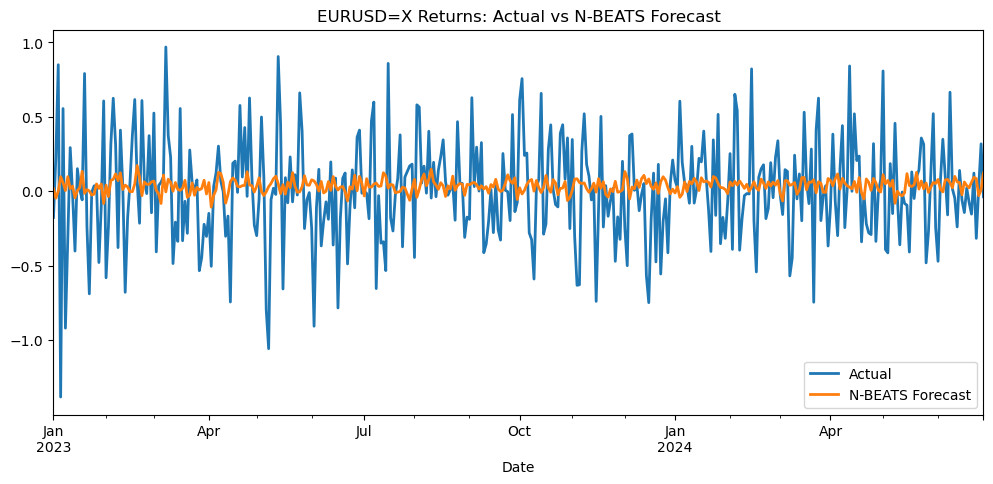

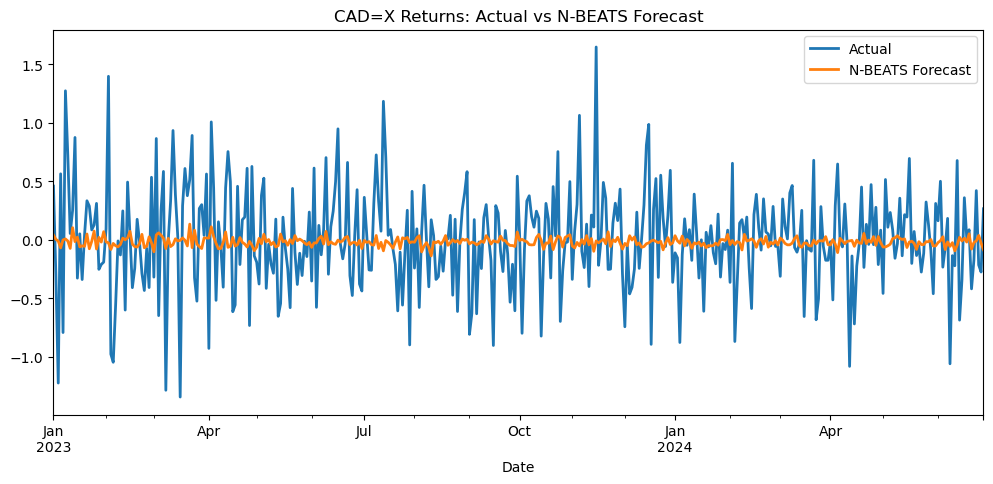

In [ ]:
for col in list(returns.columns)[1:]:
    plt.figure(figsize=(12, 5))
    
    test_ts[col].plot(label="Actual")
    pred_ts[col].plot(label="N-BEATS Forecast")
    plt.title(f"{col} Returns: Actual vs N-BEATS Forecast")

    plt.legend()
    plt.show()

In [46]:
pred = pred_ts.to_dataframe()

actual = test.copy() 
actual.set_index('Date', inplace=True)

results = pd.merge(actual, pred, left_index=True, right_index=True, how='inner')

new_columns = []
for col in list(returns.columns)[1:]:
    new_columns.append(col)
for col in list(returns.columns)[1:]:
    new_columns.append(f'{col}_forecast')

results.columns = new_columns

print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EURUSD=X           390 non-null    float64
 1   CAD=X              390 non-null    float64
 2   EURUSD=X_forecast  390 non-null    float64
 3   CAD=X_forecast     390 non-null    float64
dtypes: float64(4)
memory usage: 15.2 KB
None


,EURUSD=X,CAD=X,EURUSD=X_forecast,CAD=X_forecast
Date,,,,
2023-01-02,-0.176360,0.459449,0.017937,0.040336
2023-01-03,0.228415,-0.298977,-0.047150,0.004029
2023-01-04,0.848875,-1.225540,0.000323,-0.010846
2023-01-05,-1.382169,0.564248,0.097066,-0.069243
2023-01-06,0.554688,-0.793367,0.056557,-0.000968
...,...,...,...,...
2024-06-24,0.121303,-0.174209,0.092907,-0.023183
2024-06-25,-0.316753,0.420722,0.084740,-0.009406
2024-06-26,0.023427,-0.215266,-0.030034,0.037277


In [47]:
# save results
results.to_csv("../results/forecasts/nbeats_forecasts.csv")